--- LOADING DATASET ---


C:\Users\jayas\AppData\Local\Temp\ipykernel_4020\3573872819.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:
C:\Users\jayas\AppData\Local\Temp\ipykernel_4020\3573872819.py:53: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

Dataset Loaded! Shape: 45211 rows, 17 columns
🎯 Target Column: 'Target'

--- ENCODING CATEGORICAL VARIABLES ---

--- TRAINING THE DECISION TREE ---
Model trained successfully!

--- MODEL PERFORMANCE ---
Model Accuracy: 80.04%

--- GENERATING, SHOWING AND FORCING PATH SAVE PLOTS ---


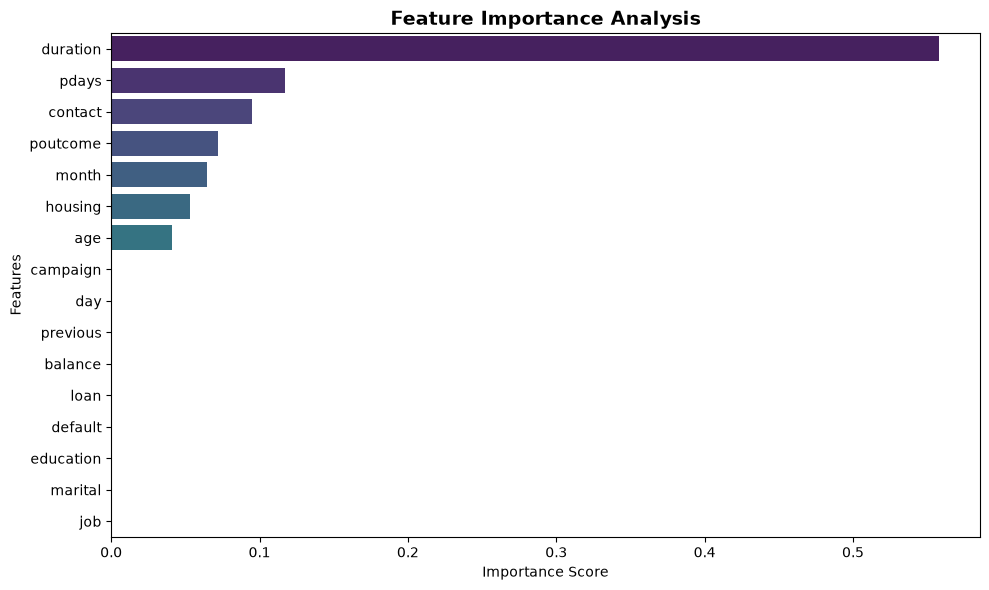

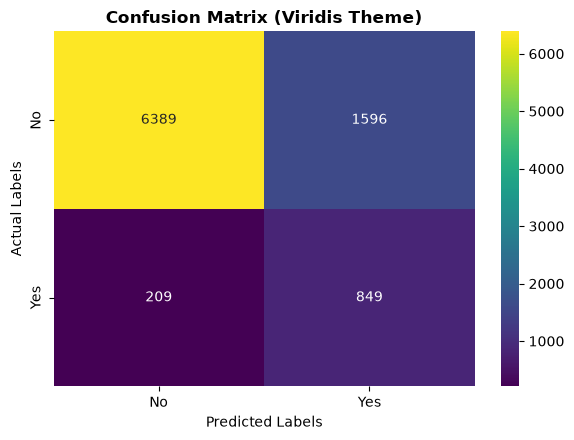

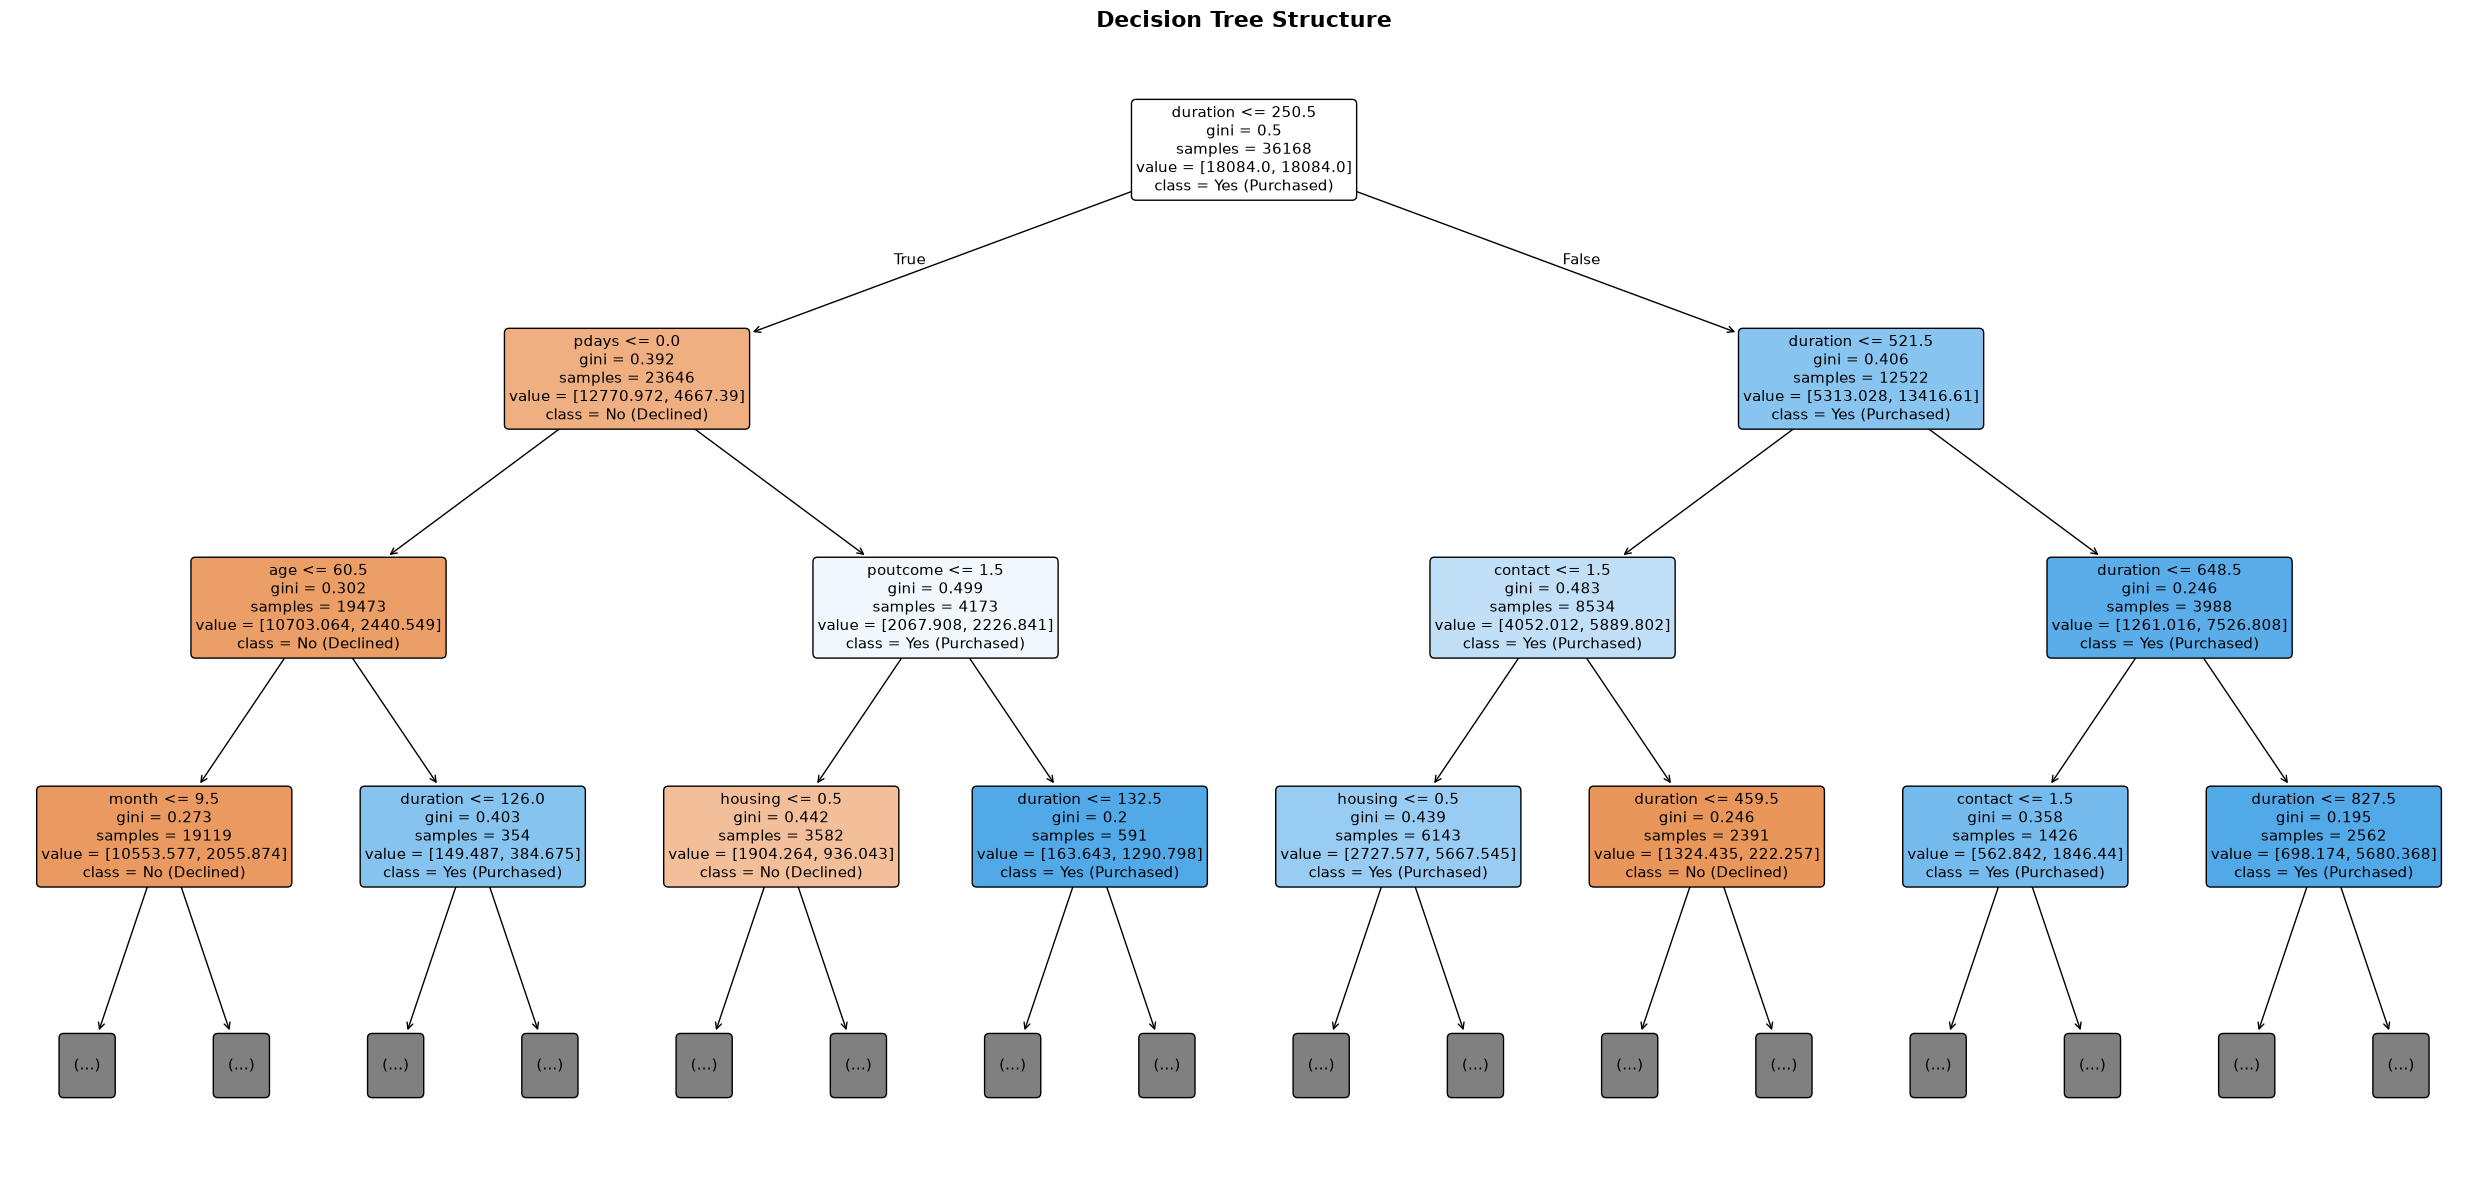


💯 SUCCESS! Your images are now definitively saved directly inside: C:\task3


In [40]:
# -*- coding: utf-8 -*-
"""
UCI Bank Marketing Dataset - Forced Direct Path Save Version
Path: C:\task3\bank-full.csv
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# STEP 1: LOAD DATASET WITH AUTO-DELIMITER
# ==========================================
print("--- LOADING DATASET ---")
df = pd.read_csv(r"C:\task3\bank-full.csv", sep=None, engine='python')

# Clean out spaces/quotes from headers
df.columns = df.columns.str.strip().str.replace('"', '').str.replace("'", "")

# Clean text formatting inside cells
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip().str.replace('"', '').str.replace("'", "")

print(f"Dataset Loaded! Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# ==========================================
# STEP 2: LOCK-IN TARGET COLUMN
# ==========================================
target_column_name = 'y'
if target_column_name not in df.columns:
    target_column_name = df.columns[-1]

print(f"🎯 Target Column: '{target_column_name}'")

# ==========================================
# STEP 3: SEPARATE FEATURES AND TARGET
# ==========================================
X = df.drop(columns=[target_column_name])
y = df[target_column_name]

# ==========================================
# STEP 4: ENCODING CATEGORICAL VARIABLES
# ==========================================
print("\n--- ENCODING CATEGORICAL VARIABLES ---")
label_encoders = {}
categorical_columns = X.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

if set(y.unique()).issubset({'yes', 'no'}):
    y = y.map({'yes': 1, 'no': 0})
else:
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)

# ==========================================
# STEP 5: TRAIN-TEST SPLIT (80% / 20%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================
# STEP 6: MODEL TRAINING
# ==========================================
print("\n--- TRAINING THE DECISION TREE ---")
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)
print("Model trained successfully!")

# ==========================================
# STEP 7: PREDICTIONS & EVALUATION
# ==========================================
print("\n--- MODEL PERFORMANCE ---")
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# ==========================================
# STEP 8: DISPLAY AND FORCE SAVE TO C:\task3\
# ==========================================
print("\n--- GENERATING, SHOWING AND FORCING PATH SAVE PLOTS ---")
save_folder = r"C:\task3"

# 1. Feature Importance Analysis
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis", hue=X.columns[indices], legend=False)
plt.title("Feature Importance Analysis", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig(os.path.join(save_folder, "feature_importance.png"), dpi=150) # Absolute Save
plt.show()

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Confusion Matrix (Viridis Theme)", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.tight_layout()
plt.savefig(os.path.join(save_folder, "confusion_matrix.png"), dpi=150)   # Absolute Save
plt.show()

# 3. Decision Tree Diagram 
plt.figure(figsize=(25, 12))
plot_tree(
    model, 
    feature_names=X.columns, 
    class_names=["No (Declined)", "Yes (Purchased)"], 
    filled=True, 
    rounded=True, 
    max_depth=3, 
    fontsize=11
)
plt.title("Decision Tree Structure", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(save_folder, "decision_tree.png"), dpi=300, bbox_inches="tight") # Absolute Save
plt.show()

print(f"\n💯 SUCCESS! Your images are now definitively saved directly inside: {save_folder}")